In [1]:
import torch
import onnxruntime as ort
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

print("✅ Imports OK")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

✅ Imports OK
PyTorch: 2.10.0+cu130
CUDA: True


En esta sección se verifica que el entorno tiene soporte para PyTorch con CUDA y para ONNX Runtime, que será el motor de inferencia principal para el modelo RT‑DETR exportado a ONNX

In [2]:
# TU MODELO
model_path = "rtdetr-l.onnx"

# Cargar sesión (CUDA primero)
session = ort.InferenceSession(model_path, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

# Info CRÍTICA shapes
input_meta = session.get_inputs()[0]
output_meta = session.get_outputs()[0]

print("🎯 MODEL INFO:")
print("Modelo:", model_path)
print("Input name:", input_meta.name)
print("Input shape:", input_meta.shape)
print("Input type:", input_meta.type)
print("Output name:", output_meta.name)
print("Output shape:", output_meta.shape)
print("Providers:", session.get_providers())
print("✅ Listo para inferencia")


🎯 MODEL INFO:
Modelo: rtdetr-l.onnx
Input name: images
Input shape: [1, 3, 640, 640]
Input type: tensor(float)
Output name: output0
Output shape: [1, 300, 84]
Providers: ['CPUExecutionProvider']
✅ Listo para inferencia


Aquí se carga el modelo RT‑DETR en formato ONNX con ONNX Runtime. Se observa que la forma de salida es (1, 300, 84), correspondiente a 300 queries y 84 valores (4 cajas + 80 scores de clases COCO).

Imagen: 640x480 -> Input: (1, 3, 640, 640)
Inferencia: 250.8ms (4.0 FPS)
Salida: N=300, clases=80
boxes_raw min/max: 0.0068/0.9875
scores min/max: 0.0002/0.8224
Detecciones finales: 5 (conf>0.25)


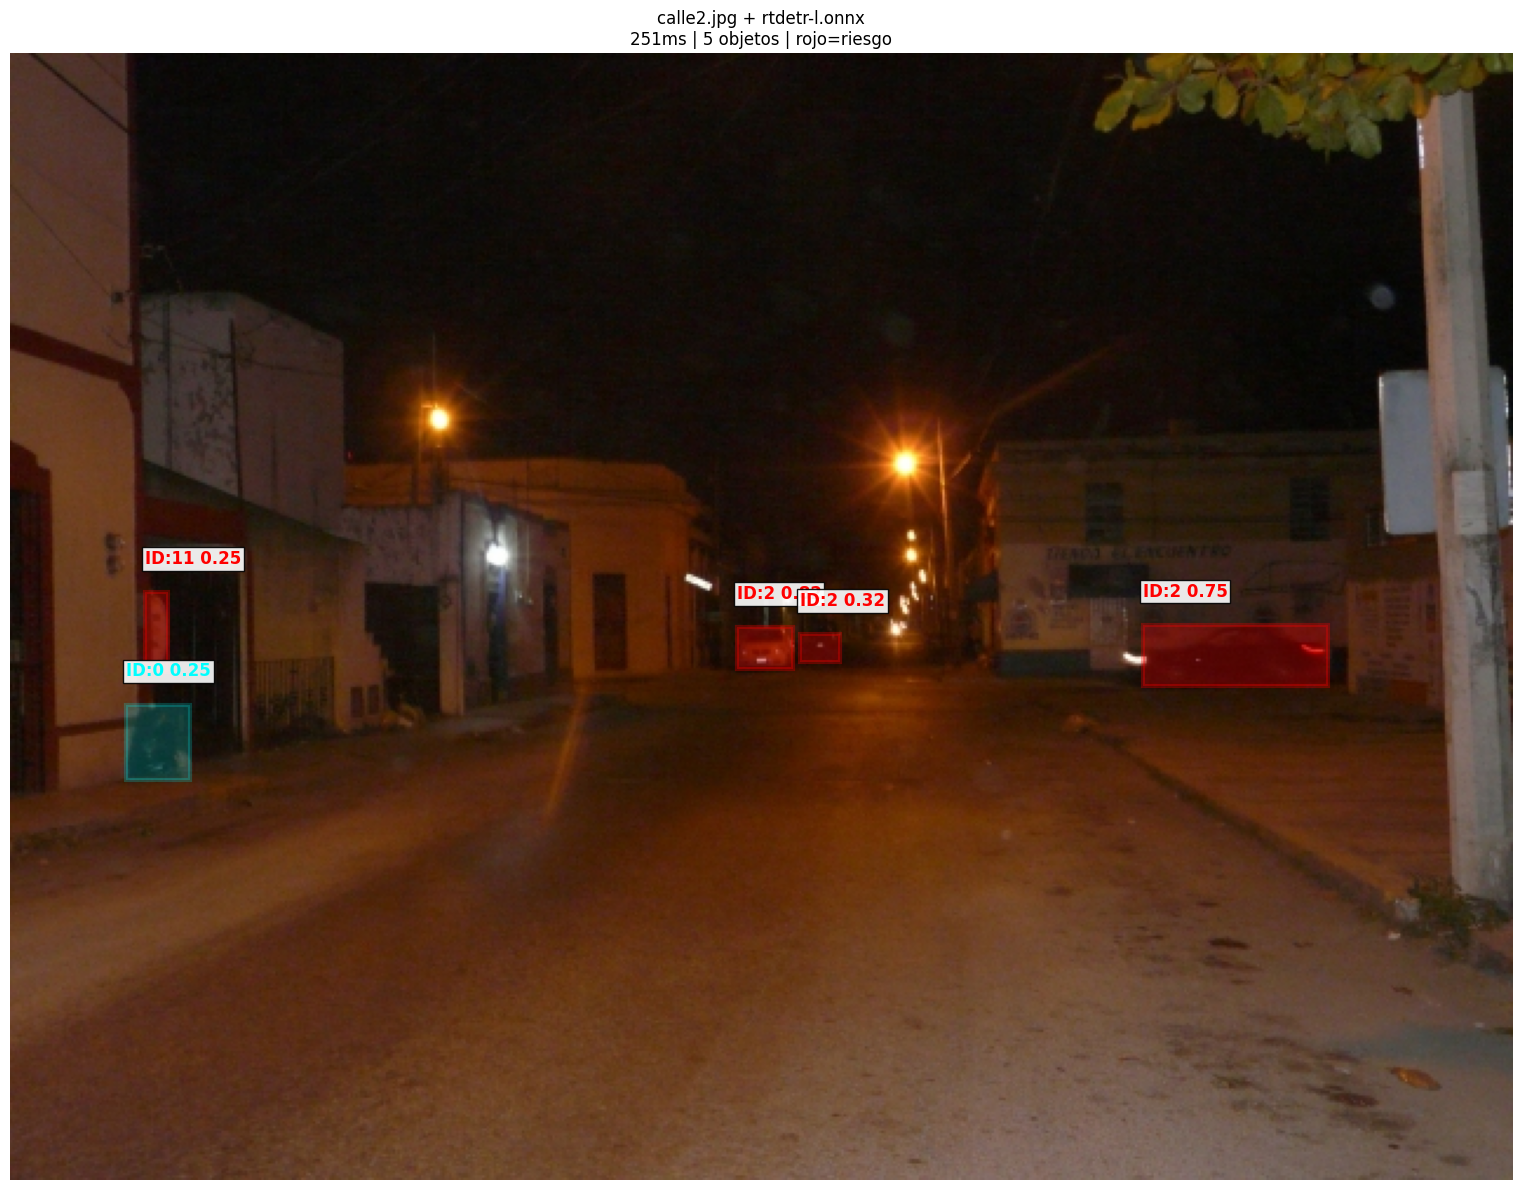


DETECCIONES:
 1. Clase  2 @ 0.82 = [309.1,244.5]...
 2. Clase  2 @ 0.75 = [482.5,243.0]...
 3. Clase  2 @ 0.32 = [336.2,247.4]...
 4. Clase 11 @ 0.25 = [57.4,229.5]...
 5. Clase  0 @ 0.25 = [49.6,277.4]...


In [8]:
# Cargar imagen
img_bgr = cv2.imread('calle1.jpg')
if img_bgr is None:
    raise FileNotFoundError("No se pudo leer 'calle2.jpg'. Verifica la ruta.")

h_orig, w_orig = img_bgr.shape[:2]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Preprocesar para RT-DETR
img_input = cv2.resize(img_rgb, (640, 640))
input_tensor = np.transpose(img_input, (2, 0, 1))[np.newaxis, ...].astype(np.float32) / 255.0

print(f"Imagen: {w_orig}x{h_orig} -> Input: {input_tensor.shape}")

# INFERENCIA
start = time.time()
ort_inputs = {input_meta.name: input_tensor}
ort_outputs = session.run(None, ort_inputs)
inference_ms = (time.time() - start) * 1000

print(f"Inferencia: {inference_ms:.1f}ms ({1000/inference_ms:.1f} FPS)")

# Parse robusto RT-DETR
output = ort_outputs[0][0]  # esperado: [N, 4 + num_classes]
if output.ndim != 2 or output.shape[1] < 6:
    raise RuntimeError(f"Salida inesperada: {output.shape}")

num_preds = output.shape[0]
num_classes = output.shape[1] - 4
boxes_raw = output[:, :4].astype(np.float32)   # cx, cy, w, h
scores = output[:, 4:].astype(np.float32)      # [N, num_classes]

# Si parecen logits, aplicar sigmoid
if scores.min() < 0 or scores.max() > 1.0:
    scores = 1.0 / (1.0 + np.exp(-scores))

scores_max = scores.max(axis=1)
class_ids = scores.argmax(axis=1)

print(f"Salida: N={num_preds}, clases={num_classes}")
print(f"boxes_raw min/max: {boxes_raw.min():.4f}/{boxes_raw.max():.4f}")
print(f"scores min/max: {scores.min():.4f}/{scores.max():.4f}")

# Detectar escala de cajas (normalizadas [0,1] o pixeles [0,640])
boxes_are_normalized = boxes_raw.max() <= 1.5

# Convertir cxcywh -> xywh para NMS de OpenCV
if boxes_are_normalized:
    cx = boxes_raw[:, 0] * 640.0
    cy = boxes_raw[:, 1] * 640.0
    bw = boxes_raw[:, 2] * 640.0
    bh = boxes_raw[:, 3] * 640.0
else:
    cx = boxes_raw[:, 0]
    cy = boxes_raw[:, 1]
    bw = boxes_raw[:, 2]
    bh = boxes_raw[:, 3]

x = cx - bw / 2.0
y = cy - bh / 2.0

# Clip para evitar tamaños negativos o fuera de imagen 640x640
x = np.clip(x, 0, 639)
y = np.clip(y, 0, 639)
bw = np.clip(bw, 1, 640)
bh = np.clip(bh, 1, 640)

boxes_xywh_640 = np.stack([x, y, bw, bh], axis=1)

# NMS + filtrado
conf_thresh = 0.25
nms_iou = 0.45
indices = cv2.dnn.NMSBoxes(
    boxes_xywh_640.tolist(),
    scores_max.tolist(),
    conf_thresh,
    nms_iou
)

detections = []
if indices is not None and len(indices) > 0:
    indices = np.array(indices).reshape(-1)
    sx = w_orig / 640.0
    sy = h_orig / 640.0

    for i in indices:
        if scores_max[i] < conf_thresh:
            continue

        x1_640 = x[i]
        y1_640 = y[i]
        x2_640 = x[i] + bw[i]
        y2_640 = y[i] + bh[i]

        x1 = float(np.clip(x1_640 * sx, 0, w_orig - 1))
        y1 = float(np.clip(y1_640 * sy, 0, h_orig - 1))
        x2 = float(np.clip(x2_640 * sx, 0, w_orig - 1))
        y2 = float(np.clip(y2_640 * sy, 0, h_orig - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        detections.append({
            'box': [x1, y1, x2, y2],
            'conf': float(scores_max[i]),
            'class_id': int(class_ids[i])
        })

print(f"Detecciones finales: {len(detections)} (conf>{conf_thresh})")

# VISUALIZACION
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
ax.imshow(img_rgb)

# COCO clases urbanas consideradas de riesgo
risky_ids = [2, 3, 5, 7, 9, 11, 13, 14]  # car,moto,bus,truck,traffic_light,stop_sign,parking_meter,bench
for det in detections:
    x1, y1, x2, y2 = map(int, det['box'])
    color = 'red' if det['class_id'] in risky_ids else 'cyan'
    alpha = 0.30 if color == 'red' else 0.20

    rect = patches.Rectangle(
        (x1, y1),
        max(1, x2 - x1),
        max(1, y2 - y1),
        linewidth=3,
        edgecolor=color,
        facecolor=color,
        alpha=alpha
    )
    ax.add_patch(rect)

    label = f"ID:{det['class_id']} {det['conf']:.2f}"
    ty = max(10, y1 - 12)
    ax.text(
        x1,
        ty,
        label,
        color=color,
        fontsize=12,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.9, pad=2)
    )

ax.set_title(
    f"calle2.jpg + rtdetr-l.onnx\n{inference_ms:.0f}ms | {len(detections)} objetos | rojo=riesgo"
)
ax.axis('off')
plt.tight_layout()
plt.show()

# Tabla resultados
print("\nDETECCIONES:")
for i, det in enumerate(detections[:10]):
    print(f"{i+1:2d}. Clase {det['class_id']:2d} @ {det['conf']:.2f} = [{det['box'][0]:.1f},{det['box'][1]:.1f}]...")

In [9]:
# DEBUG del postproceso
print("\nDEBUG POSTPROCESO:")
print(f"Predicciones totales: {len(scores_max)}")
print("Top 10 scores max:", np.round(scores_max[:10], 3))
print("Top 10 class ids:", class_ids[:10])

pre_nms = scores_max > conf_thresh
print(f"Pre-NMS > {conf_thresh}: {int(pre_nms.sum())} de {len(scores_max)}")

# NMS sobre cajas en formato correcto xywh@640
debug_indices = cv2.dnn.NMSBoxes(
    boxes_xywh_640.tolist(),
    scores_max.tolist(),
    conf_thresh,
    0.45
)
debug_nms_count = len(debug_indices) if debug_indices is not None else 0
print(f"NMS output: {debug_nms_count} boxes")

# Prueba con threshold mas bajo
conf_thresh_low = 0.10
indices_low = cv2.dnn.NMSBoxes(
    boxes_xywh_640.tolist(),
    scores_max.tolist(),
    conf_thresh_low,
    0.45
)
print(f"NMS @{conf_thresh_low}: {len(indices_low) if indices_low is not None else 0}")

# Top 5 sin NMS
top5 = np.argsort(scores_max)[-5:][::-1]
print("\nTOP 5 DETECCIONES (sin NMS):")
for i in top5:
    bx = boxes_xywh_640[i]
    print(
        f"Score: {scores_max[i]:.3f} | Clase: {class_ids[i]:2d} | "
        f"xywh640=({bx[0]:.1f},{bx[1]:.1f},{bx[2]:.1f},{bx[3]:.1f})"
    )

print("\nDetecciones finales dibujadas:", len(detections))


DEBUG POSTPROCESO:
Predicciones totales: 300
Top 10 scores max: [0.822 0.746 0.211 0.322 0.098 0.25  0.251 0.005 0.237 0.005]
Top 10 class ids: [ 2  2  7  2 24  0 11 24  0  2]
Pre-NMS > 0.25: 5 de 300
NMS output: 5 boxes
NMS @0.1: 14

TOP 5 DETECCIONES (sin NMS):
Score: 0.822 | Clase:  2 | xywh640=(309.1,326.1,24.9,24.2)
Score: 0.746 | Clase:  2 | xywh640=(482.5,324.1,79.4,35.0)
Score: 0.322 | Clase:  2 | xywh640=(336.2,329.9,17.2,16.4)
Score: 0.251 | Clase: 11 | xywh640=(57.4,306.0,9.9,45.1)
Score: 0.250 | Clase:  0 | xywh640=(49.6,369.8,26.5,42.3)

Detecciones finales dibujadas: 5
